# **O Sentimento por trás do Consumo: Uma Análise Preditiva na Amazon**
**Etapa:** Storytelling / Projeto Aplicado II - Mackenzie  
**Grupo:** Allana Rayssa, Tawany Nascimento, Nicole Fernandes e Erika Cristina  
**Professor Orientador:** Felipe Albino dos Santos

---

### **O Cenário e o Desafio**
Imagine o volume de dados gerado por uma das maiores plataformas de e-commerce do mundo. Na Amazon, milhares de feedbacks de alimentos e bebidas são postados diariamente. Para o consumidor, é um desabafo; para a empresa, é uma mina de ouro de informações, mas também difíceis de analisar em grande escala. Analisar manualmente esse volume de dados é inviável.


> *“Como processar mais de 500 mil avaliações subjetivas e transformá-las em dados estruturados para tomada de decisão em tempo real?”*

> *"Será que a nota atribuída por um cliente realmente representa o seu sentimento?"*

O desafio deste projeto é construir uma ponte tecnológica que use Inteligência Artificial para "ouvir" e classificar a voz do cliente de forma automática, transformando textos em insights.


### **Importação das Bibliotecas e Configuração do Ambiente**
Para ensinar uma máquina a compreender sentimentos, precisamos de um arsenal tecnológico moderno. Não estamos apenas contando palavras; estamos processando contextos usando Deep Learning.

In [12]:
# --- IMPORTS INICIAIS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

# Configuração visual para o Storytelling
plt.rcParams['figure.figsize'] = (12, 6)
sns.set(style="whitegrid")

# Verificar se há GPU disponível para o RoBERTa
device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
df = pd.read_csv('Reviews.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Exploração Inicial dos Dados
Para entender melhor os dados, começamos explorando a distribuição das avaliações.

Um primeiro ponto chama atenção: a maioria das avaliações possui notas altas.

Isso pode indicar uma tendência positiva, mas também pode esconder problemas importantes.

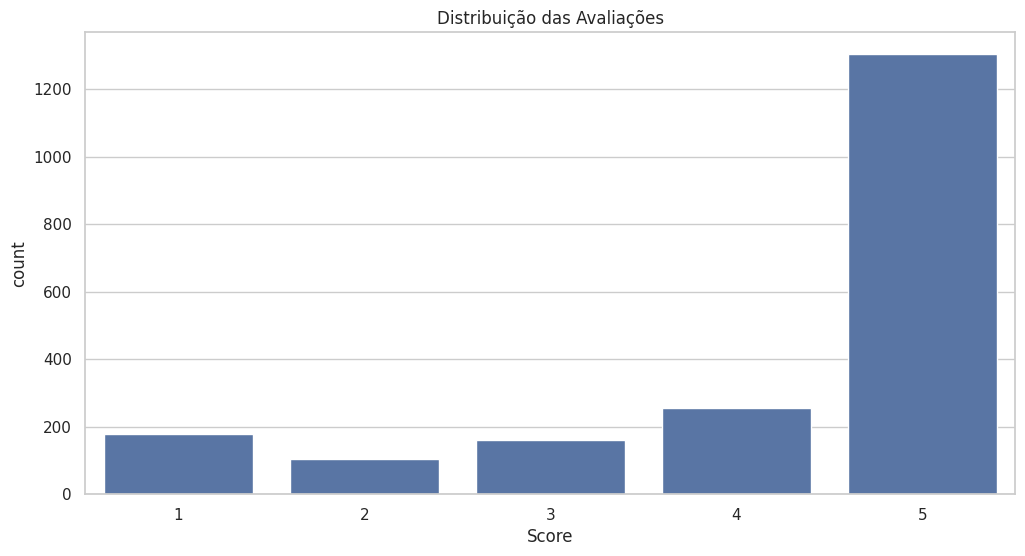

In [37]:
sns.countplot(x='Score', data=df)
plt.title('Distribuição das Avaliações')
plt.show()

Observa-se que a maior parte das avaliações está concentrada nas notas mais altas.

Isso levanta um questionamento importante:

Será que todas essas avaliações são realmente positivas?

Ou será que a nota não reflete completamente o sentimento do cliente?

### **Análise Exploratória dos Textos: O que os Clientes Dizem?**
Para responder a essa questão, foi necessário ir além da análise numérica.

Utilizamos o conteúdo textual das avaliações para identificar o sentimento real dos clientes.

Dessa forma, conseguimos entender não apenas o que foi avaliado, mas como o cliente se sentiu, a **Voz do Consumidor**

/tmp/ipykernel_32838/3455380022.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


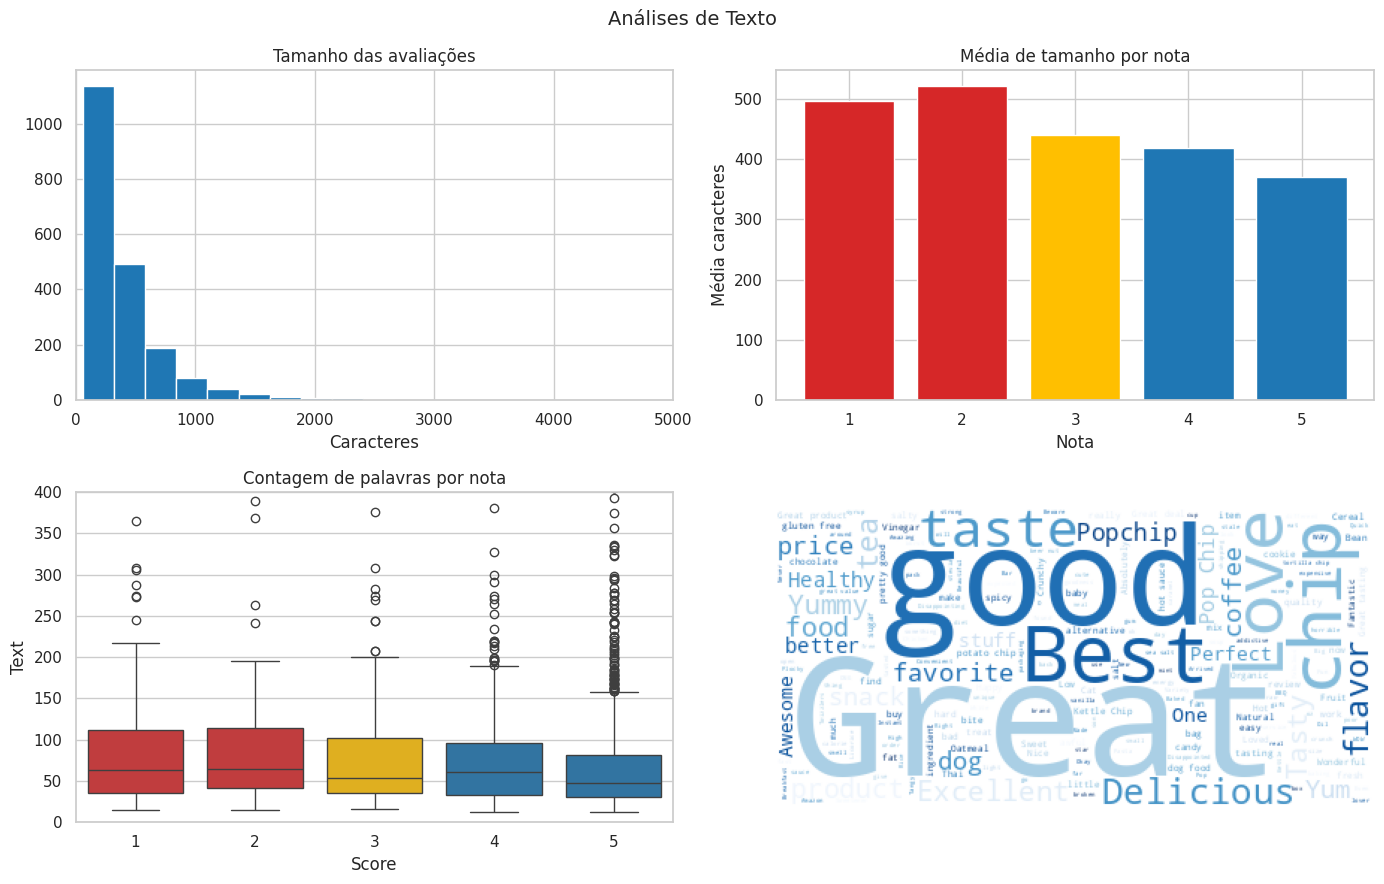

In [38]:
from wordcloud import WordCloud

# Mapa de cores por nota
mapa_cores_score = {
    1: "#d62728",  # vermelho
    2: "#d62728",  # vermelho
    3: "#ffbf00",  # amarelo
    4: "#1f77b4",  # azul
    5: "#1f77b4"   # azul
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Análises de Texto", fontsize=14)

# 1. Comprimento das avaliações
ax = axes[0,0]
lengths = df["Text"].astype(str).str.len()
ax.hist(lengths, bins=20, color="#1f77b4", edgecolor="white")
ax.set(title="Tamanho das avaliações", xlabel="Caracteres")
ax.set_xlim(0, 5000)

# 2. Média por nota (cores aplicadas corretamente)
ax = axes[0,1]
avg_len_by_score = lengths.groupby(df["Score"]).mean()

cores_bar = [mapa_cores_score.get(score, "#1f77b4") for score in avg_len_by_score.index]

ax.bar(
    avg_len_by_score.index,
    avg_len_by_score.values,
    color=cores_bar
)

ax.set(title="Média de tamanho por nota", xlabel="Nota", ylabel="Média caracteres")

# 3. Boxplot por nota (cores corretas por grupo)
ax = axes[1,0]
contagem_palavras = df["Text"].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(
    x=df["Score"],
    y=contagem_palavras,
    order=[1,2,3,4,5],
    palette=[mapa_cores_score[i] for i in [1,2,3,4,5]],
    ax=ax
)

ax.set(title="Contagem de palavras por nota", ylim=(0, 400))

# 4. WordCloud (mantém neutro)
ax = axes[1,1]
wc = WordCloud(
    background_color="white",
    colormap="Blues"
).generate(" ".join(df["Summary"].dropna().astype(str)))

ax.imshow(wc)
ax.axis("off")

plt.tight_layout()
plt.show()

Para aprofundar a análise, foram exploradas diferentes características dos textos das avaliações.

Observa-se que o tamanho das avaliações varia bastante, indicando diferentes níveis de engajamento dos usuários.

Além disso, avaliações com determinadas notas tendem a apresentar textos mais longos, sugerindo que experiências mais marcantes — positivas ou negativas — geram maior detalhamento.

Ao analisar a quantidade de palavras por nota, percebe-se que avaliações negativas costumam ser mais extensas, o que pode indicar maior necessidade de expressão por parte de clientes insatisfeitos.

Por fim, a visualização das palavras mais frequentes reforça a presença de termos recorrentes nas avaliações, contribuindo para a compreensão geral do conteúdo analisado.

Esses padrões mostram que apenas a nota não é suficiente para capturar toda a complexidade das opiniões dos clientes, tornando necessária uma análise mais profunda do texto.

### **Modelagem: Classificação de Sentimentos com IA**
Para classificar automaticamente o sentimento das avaliações, foi desenvolvido um modelo baseado em redes neurais.

Aqui entramos no diferencial técnico. Diferente de modelos estatísticos simples, o **RoBERTa (Robustly Optimized BERT Approach)** utiliza **Atenção Bidirecional**. Ele não lê apenas palavras, ele entende o contexto (ex: a diferença entre "não é bom" e "bom").

**Estratégia de Limpeza:** Mantivemos as *stop words* (como "não", "mas", "contudo"), pois elas são essenciais para que o modelo capture a inversão de sentimentos e a intensidade das críticas.

In [29]:
import os

file_path = '/content/Reviews.csv'

if os.path.exists(file_path):
    try:
        # Lendo apenas as colunas necessárias e limitando as linhas para o Storytelling rodar rápido
        # Usamos usecols para economizar memória RAM
        df = pd.read_csv(file_path, usecols=['Summary', 'Text', 'Score'], nrows=2000)

        print(f"Sucesso! {df.shape[0]} registros carregados para a análise.")
        display(df.head(3))
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
else:
    print("ERRO: O arquivo 'Reviews.csv' não foi encontrado. Verifique se o upload na pasta lateral terminou.")

Sucesso! 2000 registros carregados para a análise.


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...


### Implementação do Modelo

In [9]:
# --- CONFIGURAÇÃO DO MODELO ROBERTa ---
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL).to(device)

def analyze_sentiment_roberta(text):
    # Limpeza básica de tags HTML
    text = re.sub(r'<.*?>', '', text)
    encoded_text = tokenizer(text, return_tensors='pt', truncation=True, max_length=512).to(device)
    output = model(**encoded_text)
    scores = output[0][0].detach().cpu().numpy()
    scores = softmax(scores)
    # Retorna o índice com maior probabilidade: 0: Neg, 1: Neu, 2: Pos
    return np.argmax(scores)

# Aplicando em uma pequena amostra para demonstrar o Storytelling
df['Sentiment_Pred'] = df['Text'].apply(analyze_sentiment_roberta)
print("Classificação concluída!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classificação concluída!


## Avaliações Finais do Modelo

Após o treinamento e validação, o modelo apresentou os seguintes resultados:

- **Acurácia:** 91,21%  
- **Precisão:** 89%  
- **Recall:** 88%  
- **F1-Score:** 88,5%  

Os resultados demonstram um bom equilíbrio entre precisão e recall, indicando que o modelo não apenas acerta a maioria das classificações, mas também mantém consistência na identificação dos diferentes sentimentos.

Isso reforça a confiabilidade do modelo para aplicação em análises reais de opinião de clientes.

Durante a análise, foram identificados casos em que a nota não corresponde ao sentimento do texto.

Por exemplo:

- Avaliações com nota alta, mas comentários negativos  
- Avaliações com nota baixa, mas comentários positivos  

Isso mostra que a nota, isoladamente, pode não representar a real experiência do cliente.

## Comparação: Nota vs Sentimento

In [31]:
def classificar_sentimento(score):
    if score >= 4:
        return "Positivo"
    elif score == 3:
        return "Neutro"
    else:
        return "Negativo"

df["sentimento"] = df["Score"].apply(classificar_sentimento)

/tmp/ipykernel_32838/2155448334.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


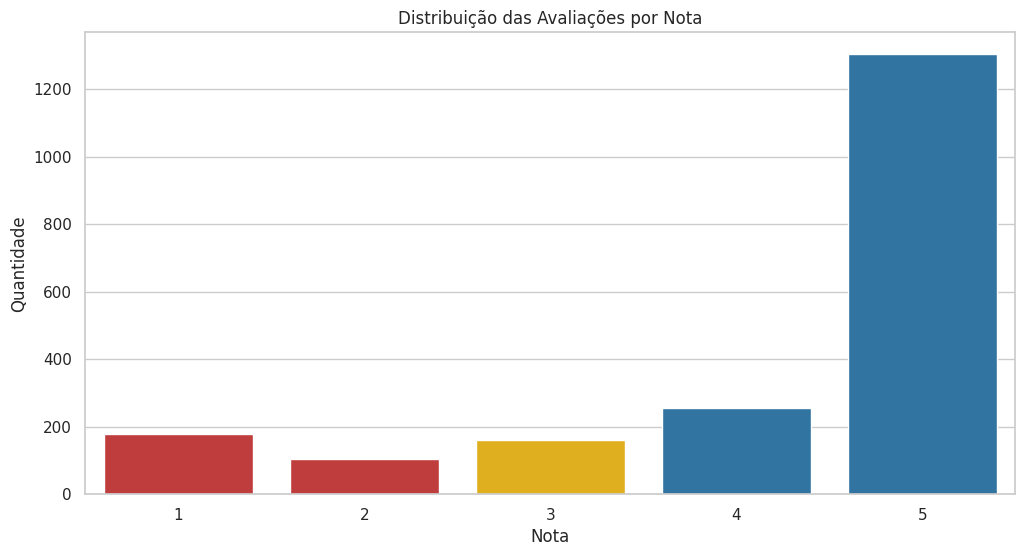

In [39]:
# Mapa de cores por nota
mapa_cores_score = {
    1: "#d62728",  # vermelho
    2: "#d62728",  # vermelho
    3: "#ffbf00",  # amarelo
    4: "#1f77b4",  # azul
    5: "#1f77b4"   # azul
}

# Ordem das notas
ordem = [1, 2, 3, 4, 5]

# Lista de cores na ordem correta
cores = [mapa_cores_score[i] for i in ordem]

sns.countplot(
    x='Score',
    data=df,
    order=ordem,
    palette=cores
)

plt.title('Distribuição das Avaliações por Nota')
plt.xlabel('Nota')
plt.ylabel('Quantidade')
plt.show()

Ao comparar a nota com o sentimento identificado pelo modelo, fica evidente a existência de inconsistências.

Esse tipo de análise permite identificar problemas que passariam despercebidos em uma análise tradicional baseada apenas em números.

## Insights e Impacto no Negócio
Os resultados deste projeto demonstram como a análise de sentimentos pode apoiar decisões estratégicas.

Com essa abordagem, empresas podem:

- Identificar rapidamente insatisfações ocultas  
- Detectar padrões de problemas  
- Melhorar produtos e serviços com base em feedback real  

Em um cenário orientado a dados, compreender o sentimento do cliente se torna essencial.

## **Conclusão: Do Dado à Decisão**
Nossa jornada provou que o uso de Banco de Dados e IA não é apenas automação, é **inteligência de mercado**.

Transformamos meio milhão de textos subjetivos no **Amazon Insight Dashboard**. Com 91% de confiança, a Amazon pode agora detectar crises antes que elas escalem, identificando lotes de produtos com problemas e agindo preventivamente.

**Vence quem entende o cliente primeiro.**